# Imports + Load Data

In [4]:
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns

tf.random.set_seed(42)

df = pd.read_csv("../data/processed/cleaned_fake_news.csv")

df = df.dropna(subset=["clean_text"])
df = df[df["clean_text"].str.strip() != ""]

X = df["clean_text"].astype(str).to_numpy()
y = df["label"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 35239
Test size: 8810


# Tokenization

In [5]:
max_words = 20000
max_len = 300

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Load GloVe Embeddings

In [7]:
embeddings_index = {}

with open("../data/glove/glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

embedding_dim = 100
word_index = tokenizer.word_index

embedding_matrix = np.zeros((max_words, embedding_dim))

for word, i in word_index.items():
    if i < max_words:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

print("Embedding matrix created:", embedding_matrix.shape)

Embedding matrix created: (20000, 100)


# Build LSTM Model

In [8]:
model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True
    ),
    LSTM(128, dropout=0.3, recurrent_dropout=0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

# Training

In [9]:
class_weights_arr = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights_arr))

early_stop = EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

Epoch 1/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 151s 300ms/step - accuracy: 0.9294 - loss: 0.1898 - val_accuracy: 0.9725 - val_loss: 0.0849
Epoch 2/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 157s 317ms/step - accuracy: 0.9680 - loss: 0.0942 - val_accuracy: 0.9827 - val_loss: 0.0484
Epoch 3/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 151s 303ms/step - accuracy: 0.9848 - loss: 0.0460 - val_accuracy: 0.9932 - val_loss: 0.0213
Epoch 4/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 155s 313ms/step - accuracy: 0.9946 - loss: 0.0166 - val_accuracy: 0.9946 - val_loss: 0.0162
Epoch 5/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 156s 314ms/step - accuracy: 0.9975 - loss: 0.0092 - val_accuracy: 0.9952 - val_loss: 0.0144
Epoch 6/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 173s 350ms/step - accuracy: 0.9983 - loss: 0.0055 - val_accuracy: 0.9955 - val_loss: 0.0162
Epoch 7/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 172s 347ms/step - accuracy: 0.9990 - loss: 0.0033 - val_accuracy: 0.9960 - val_loss: 0.0178
Epoch 8/15
496/496 ━━━━━━━━━━━━━━━━━━━━ 230s 463ms/step - accuracy: 0.9993 -

# Evaluation

In [10]:
y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

276/276 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step
Accuracy: 0.9963677639046538

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4242
           1       1.00      0.99      1.00      4568

    accuracy                           1.00      8810
   macro avg       1.00      1.00      1.00      8810
weighted avg       1.00      1.00      1.00      8810



# Confusion Matrix

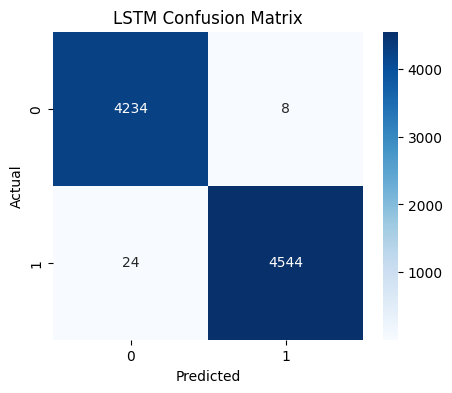

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Training Curve

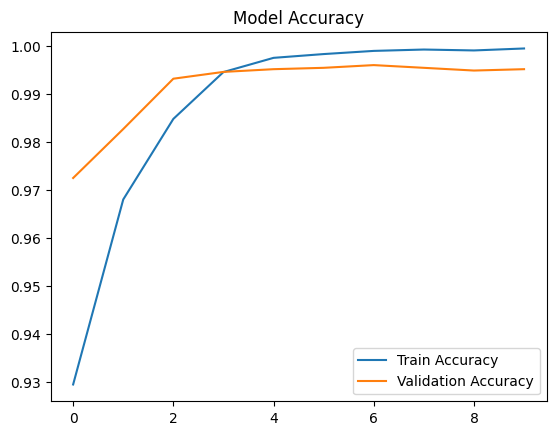

In [12]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()

# Explainability

In [13]:
def explain_text(text, top_n=10):
    words = text.lower().split()

    def predict_prob(word_list):
        seq = tokenizer.texts_to_sequences([" ".join(word_list)])
        padded = pad_sequences(seq, maxlen=300)
        return model.predict(padded, verbose=0)[0][0]

    base_prob = predict_prob(words)
    scores = []
    for i, word in enumerate(words):
        masked = words[:i] + ["<OOV>"] + words[i+1:]
        delta = base_prob - predict_prob(masked)
        scores.append((word, delta))

    scores.sort(key=lambda x: abs(x[1]), reverse=True)
    label = "Fake" if base_prob > 0.5 else "Real"
    important_words = [w for w, _ in scores[:top_n]]
    return label, important_words


# TEST EXAMPLE
sample = "Breaking news: shocking discovery about government corruption scandal"

label, reasons = explain_text(sample)

print("Prediction:", label)
print("Words contributing:", reasons)

Prediction: Fake
Words contributing: ['news:', 'shocking', 'government', 'breaking', 'corruption', 'discovery', 'scandal', 'about']


# SAVE LSTM MODEL

In [14]:
import json
import os
import datetime

os.makedirs("../outputs/models", exist_ok=True)

# native Keras format — avoids HDF5 deprecation warning
model.save("../outputs/models/lstm_model.keras")

# JSON serialisation — stable across TensorFlow/Keras versions
tokenizer_json = tokenizer.to_json()
with open("../outputs/models/tokenizer.json", "w", encoding="utf-8") as f:
    json.dump(tokenizer_json, f)

y_pred_flat = (model.predict(X_test_pad) > 0.5).astype("int32").flatten()
metadata = {
    "trained_at": datetime.datetime.now().isoformat(),
    "accuracy": float(accuracy_score(y_test, y_pred_flat)),
    "params": {"max_words": 20000, "max_len": 300, "epochs": "early_stopped", "batch_size": 64}
}
with open("../outputs/models/lstm_model_meta.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("LSTM model + tokenizer saved")

276/276 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step
LSTM model + tokenizer saved
